# 01. From a photon to a numerical input

This notebook follows one simulated photon from its physical context to crystal deposits, labels and a numerical representation. It audits sampling, units, coordinates and sensitivity to a crystal threshold. Saved outputs are included; no model is trained here.

Data: [Maidannyk and Sahin, Zenodo 18929909](https://zenodo.org/records/18929909), version 0.0.1, CC BY 4.0. The [data report](../docs/data_audit.md) consolidates provenance and the ROOT cross-check.

The grid/patch demonstration documents the original full-grid pilot. The selected method uses local 7 x 7 windows with cell tokens; continue with [Methods and decisions](02_methods_and_decisions.ipynb) after this audit.


## 1. The physical event

An incident photon enters the simulated detector. Interactions create an electromagnetic shower, a cascade of secondary particles. Energy is deposited across calorimeter crystals. One number in the grid represents the recorded deposit in one crystal.

**Incident photon -> simulated shower -> crystal deposits -> grid -> future encoder -> estimated energy and impact position.**

The simulation also supplies the incident energy and impact coordinates as labels. These are quantities to predict, not input features. Deposited energy can differ from incident energy because some energy is not recorded in the active volume.

These are simulated single-photon events in a CMS-inspired detector segment. They are neither collision data nor a full CMS detector simulation.


In [1]:
import json
import os
from pathlib import Path

import numpy as np

from calolab_reco.data import data_root, load_prepared

cache_root = Path(
    os.environ.get("CALOLAB_CACHE_ROOT", Path.home() / "Data/cache/calolab-reco")
).expanduser()
os.environ.setdefault("MPLCONFIGDIR", str(cache_root / "matplotlib"))

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

root = data_root()
prepared = root / "derived" / "audit_v1"
if not (prepared / "manifest.json").exists():
    raise FileNotFoundError("Run the documented audit and prepare commands first.")
manifest = json.loads((prepared / "manifest.json").read_text())
train = load_prepared(root, split="train")
x = train["deposits"]
y = train["targets"]
ids = train["source_ids"]
print("Verified derived-file hashes.")
print("Training input:", x.shape, x.dtype)
# Display names reflect the ROOT cross-check; the stored manifest is unchanged.
target_names = ["incident_energy_raw", "impact_iphi_raw", "impact_ieta_raw"]
print("Training labels:", y.shape, target_names)
print("No validation or test examples loaded.")

Verified derived-file hashes.
Training input: (28118, 30, 85) float32
Training labels: (28118, 3) ['incident_energy_raw', 'impact_iphi_raw', 'impact_ieta_raw']
No validation or test examples loaded.


## 2. The full dataset and the working sample

**A group is a storage chunk, not a particle category or a train/test partition.** The authors stored 2,200,000 events in 220 chunks of 10,000 events.

Three archives hold matching information. For example, event 42 in group 7 uses:

| Archive | Entry for that event |
| --- | --- |
| Deposits | `X_7[42]`: one 30 x 85 grid |
| Incident energy | `en_7[42]`: one energy label |
| Position | `yc_7[42]`: two coordinates |

The external data directory contains:

- `raw/`: all 2.2 million events in the three compressed archives, about **1.69 GB**.
- `derived/audit_v1/`: an additional working sample of **40,000 events**, about **0.409 GB**.

The other events remain in the original archives. No dataset is stored in the project repository. The 40,000-event sample bounds the planned training and comparison cost; the [T4 pilot](../docs/data_audit.md#compute-feasibility) supports its compute feasibility, with full training outcomes now available in the final report. The full numerical arrays occupy about **22.47 GB** when decompressed; preparation reads one group array at a time without extracting the whole corpus.


In [2]:
inventory = manifest["inventory"]
print("Source groups:", len(inventory["groups"]))
print("Source events:", f"{inventory['n_events']:,}")
print("Largest decoded array (MiB):", round(inventory["largest_array_bytes"] / 2**20, 2))
print(
    "All decoded arrays (GiB, not extracted):",
    round(inventory["total_decompressed_array_bytes"] / 2**30, 2),
)
print("Sample events:", manifest["parameters"]["sample_size"])
print("Train / validation / test counts:", manifest["split_counts"])
print("Training groups represented:", len(np.unique(ids[:, 0])))

Source groups: 220
Source events: 2,200,000
Largest decoded array (MiB): 97.27
All decoded arrays (GiB, not extracted): 20.92
Sample events: 40000
Train / validation / test counts: {'train': 28118, 'validation': 5947, 'test': 5935}
Training groups represented: 220


## 3. Follow one training event

The first retained training event is selected by storage order. It contains **30 x 85 = 2550** deposit values and three separate target labels.

| Quantity | Interpretation | Evidence and limit |
| --- | --- | --- |
| Incident energy | GeV, strongly inferred | The documented 1 to 100 GeV range matches the stored labels and ROOT InitialMomentum. |
| Deposits and their sum | MeV, strongly inferred | In 10,000 ROOT events, sum(EnergyVector) / 1000 equals TotalEn to numerical precision; NPZ preserves these deposits. Exported fields do not declare units explicitly. |
| Impact iphi | Fractional cell coordinate along the 30 rows | NPZ coordinate_0 equals float32(InitialRow + 15). |
| Impact ieta | Fractional cell coordinate along the 85 columns | NPZ coordinate_1 equals float32(InitialColumn). |

**1 GeV = 1000 MeV.** On this interpretation, about 79,118 stored deposit units correspond to 79.118 GeV, compared with an incident energy near 82.379 GeV. The arrays remain as stored; this notebook does not change the training inputs.

The axis names are established by the [ROOT comparison](../docs/data_audit.md#direct-root-to-npz-comparison) and the [producer's branch descriptions](https://zenodo.org/records/18929909). The mapping was verified on source group 0 only. Cell-center conventions remain unresolved: iphi and ieta are not coordinates in centimeters or automatically angles in radians. No truth impact is overlaid on the cell plots.


In [3]:
event = x[0]
labels = y[0]
print("Storage identifier (group, row):", tuple(int(value) for value in ids[0]))
print("Grid [iphi rows, ieta columns]:", event.shape)
print("Incident energy [GeV, inferred]:", float(labels[0]))
print("Impact iphi [fractional cell coordinate]:", float(labels[1]))
print("Impact ieta [fractional cell coordinate]:", float(labels[2]))
print("Cell-center convention: unresolved; no coordinate offset is added here.")
print("Sum of deposits [MeV, inferred]:", float(event.sum(dtype=np.float64)))
print("Positive cells:", int((event > 0).sum()), "of", event.size)
print("Zero cells:", int((event == 0).sum()))

Storage identifier (group, row): (0, 21)
Grid [iphi rows, ieta columns]: (30, 85)
Incident energy [GeV, inferred]: 82.37901306152344
Impact iphi [fractional cell coordinate]: 6.2107768058776855
Impact ieta [fractional cell coordinate]: 75.14381408691406
Cell-center convention: unresolved; no coordinate offset is added here.
Sum of deposits [MeV, inferred]: 79117.75463519292
Positive cells: 174 of 2550
Zero cells: 2376


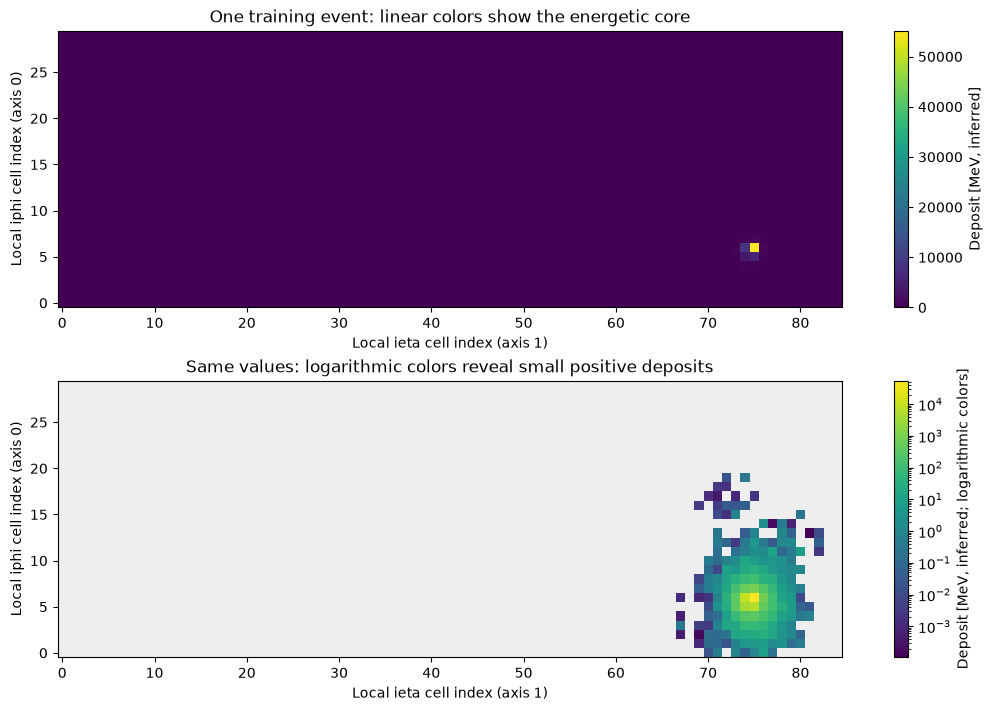

In [4]:
cmap = plt.colormaps["viridis"].copy()
cmap.set_bad("#eeeeee")
positive_event = np.ma.masked_less_equal(event, 0)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
linear_image = axes[0].imshow(event, origin="lower", cmap="viridis", aspect="equal")
fig.colorbar(linear_image, ax=axes[0], label="Deposit [MeV, inferred]")
log_image = axes[1].imshow(
    positive_event,
    origin="lower",
    cmap=cmap,
    norm=LogNorm(vmin=positive_event.min(), vmax=positive_event.max()),
    aspect="equal",
)
fig.colorbar(log_image, ax=axes[1], label="Deposit [MeV, inferred; logarithmic colors]")
axes[0].set_title("One training event: linear colors show the energetic core")
axes[1].set_title("Same values: logarithmic colors reveal small positive deposits")
for axis in axes:
    axis.set_xlabel("Local ieta cell index (axis 1)")
    axis.set_ylabel("Local iphi cell index (axis 0)")
plt.show()

Both panels display the **same values**. Only the color mapping changes. Light gray in the lower panel denotes stored zero deposits. No input normalization, noise addition or threshold was applied.

The horizontal direction is ieta and the vertical direction is iphi. Plotting a pixel at index 0 does not establish the producer's cell-center convention. These are simulated deposits, not a fully simulated detector readout.


## 4. Original grid and patch representation

| Representation | Description | Role in the original pilot |
| --- | --- | --- |
| Dense grid | One value for every indexed crystal, including stored zeros | Complete 30 x 85 input grid |
| Sparse cell list | Deposit and coordinates for each retained cell | Alternative representation, outside the planned comparison |
| Graph | Cells plus explicit neighborhood connections | Useful for irregular geometry; outside this comparison |
| Patch tokens | Group grid values into ordered vectors, then learn an embedding | Transformer input derived from the same full grid |

The regular rectangular storage makes a grid a simple common representation. The pilot CNN accepts deposits with shape `(B, 1, 30, 85)`, where `B` is the batch size and 1 is the deposit channel. It adds fixed row/column index channels. The Transformer represents those locations through fixed 2D patch positions; these index features do not assume physical cell-center coordinates.

For the original full-grid Transformer, 5 x 5 patches give **6 x 17 = 102 patches**, each with **25 ordered values**. No averaging is required and the grid divides exactly, so data padding is unnecessary. A learned linear layer maps each 25-value vector to width 64; a fixed positional vector of the same width is then added.

Grouping values is reversible. A learned projection is a separate operation and does not guarantee information preservation.


In [5]:
# This is a representation demonstration, not an implemented model.
patch_grid = event.reshape(6, 5, 17, 5).transpose(0, 2, 1, 3)
patches = patch_grid.reshape(102, 25)
restored = patches.reshape(6, 17, 5, 5).transpose(0, 2, 1, 3).reshape(30, 85)
np.testing.assert_array_equal(restored, event)
assert not np.shares_memory(patches, labels)

print("Single-event CNN deposit input:", event[None, None].shape)
print("Patch grid:", patch_grid.shape)
print("Ordered patch vectors:", patches.shape)
print("Exact recovery of all 2550 original values: passed")
print("Labels remain separate:", labels.shape)

Single-event CNN deposit input: (1, 1, 30, 85)
Patch grid: (6, 17, 5, 5)
Ordered patch vectors: (102, 25)
Exact recovery of all 2550 original values: passed
Labels remain separate: (3,)


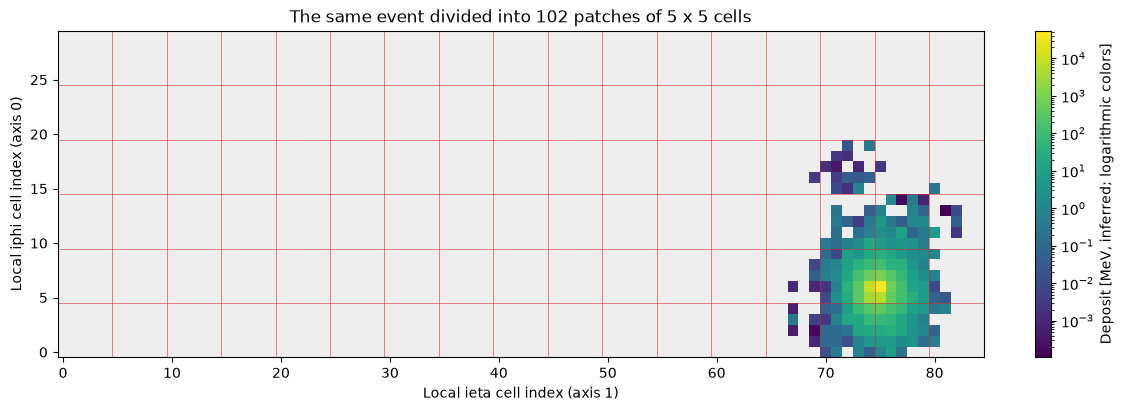

In [6]:
fig, axis = plt.subplots(figsize=(12, 4), constrained_layout=True)
image = axis.imshow(positive_event, origin="lower", cmap=cmap, norm=log_image.norm)
for boundary in np.arange(4.5, 85, 5):
    axis.axvline(boundary, color="tab:red", linewidth=0.6, alpha=0.65)
for boundary in np.arange(4.5, 30, 5):
    axis.axhline(boundary, color="tab:red", linewidth=0.6, alpha=0.65)
axis.set(
    title="The same event divided into 102 patches of 5 x 5 cells",
    xlabel="Local ieta cell index (axis 1)",
    ylabel="Local iphi cell index (axis 0)",
)
fig.colorbar(image, ax=axis, label="Deposit [MeV, inferred; logarithmic colors]")
plt.show()

A **stored zero** means no deposited energy in that simulated crystal. It does not establish the value that a noisy detector would read. A **masked patch** is deliberately hidden during pretraining; its original values may include positives and zeros. **Padding** would represent a nonexistent cell, but is not needed for this grid and patch size.

The pilot uses `log1p(deposit / s)`, with one positive scale fitted on train. This audit displays the original values; its logarithmic plot colors do not modify those arrays. Dividing each event by its own total would remove useful absolute-energy information. Dividing by the true incident energy or position would leak the prediction target.

The selected local method uses a linear train-only scale and 49 cell tokens. Local windows near the array boundary do need explicit padding and validity.


## 5. Quality checks and reproducible sampling

Preparation first samples 40,000 events, then assigns them to train, validation and test.

Only structural validity and anomaly counts were examined across the selected sample. Descriptive statistics below use train only. The test is reserved for final performance evaluation after model and protocol choices are frozen.

Exact duplicate deposit maps are grouped before train/validation/test assignment. The split seed is independent of the sampling seed. This protects against exact duplicate maps across train, validation and test, but cannot discover hidden physical relationships without identifiers supplied by the producer.

No row was dropped or corrected. A nonfinite value, negative deposit or empty event would require an explicit selection decision before learning.


In [7]:
print("Sampling and split seeds:", manifest["parameters"])
print("Quality counts:", json.dumps(manifest["quality"], indent=2))
print("Extra exact duplicate maps:", manifest["duplicate_extra_events"])
print(
    "Duplicate groups with conflicting labels:", manifest["duplicate_groups_with_different_targets"]
)
print("Duplicate-control limit:", manifest["duplicate_control_limit"])

assignment = np.load(prepared / "split.npy", mmap_mode="r", allow_pickle=False)
source_ids = np.load(prepared / "source_ids.npy", mmap_mode="r", allow_pickle=False)
assert np.isin(assignment, [0, 1, 2]).all()
assert len(np.unique(source_ids, axis=0)) == len(source_ids)
assert sum(manifest["split_counts"].values()) == len(source_ids)
for name, value in {"train": 0, "validation": 1, "test": 2}.items():
    assert int((assignment == value).sum()) == manifest["split_counts"][name]
print("One assignment per unique storage row and partition counts: passed")
print("Groups represented in the full sample:", len(np.unique(source_ids[:, 0])))

Sampling and split seeds: {'sample_size': 40000, 'sample_seed': 20260920, 'split_seed': 20260921}
Quality counts: {
  "nonfinite_deposit_values": 0,
  "negative_deposit_values": 0,
  "all_zero_events": 0,
  "nonfinite_target_values": 0,
  "nonpositive_incident_energy_events": 0
}
Extra exact duplicate maps: 0
Duplicate groups with conflicting labels: 0
Duplicate-control limit: Exact stored deposit maps within the selected sample only


One assignment per unique storage row and partition counts: passed
Groups represented in the full sample: 220


## 6. Energy units: evidence before conversion

The ROOT cross-check establishes **sum(EnergyVector) / 1000 = TotalEn** on 10,000 events. NPZ deposits match EnergyVector and incident labels match InitialMomentum after float32 rounding. With the documented 1 to 100 GeV photon range, this strongly supports MeV deposits and GeV incident labels; the export has no explicit unit annotations. See the [cross-check](../docs/data_audit.md#energy-units-noise-and-threshold).

The raw ratio below uses labels for an audit, **never as an input feature**. Converting MeV to GeV uses exactly 1000. It must not use a fitted factor that forces deposited energy to equal incident energy: energy loss and unit conversion remain distinct.

The small positive deposits also show that these inputs have not received a blanket 50 MeV cut under this unit interpretation. The final cells measure the sensitivity to such a cut; detector noise is studied separately in the subsequent methodology experiments.


Median raw deposit-sum / energy-label: 978.6537078696683
Median positive-cell count: 165.0 out of 2550
Smallest positive training deposit, stored units: 7.916241884231567e-09


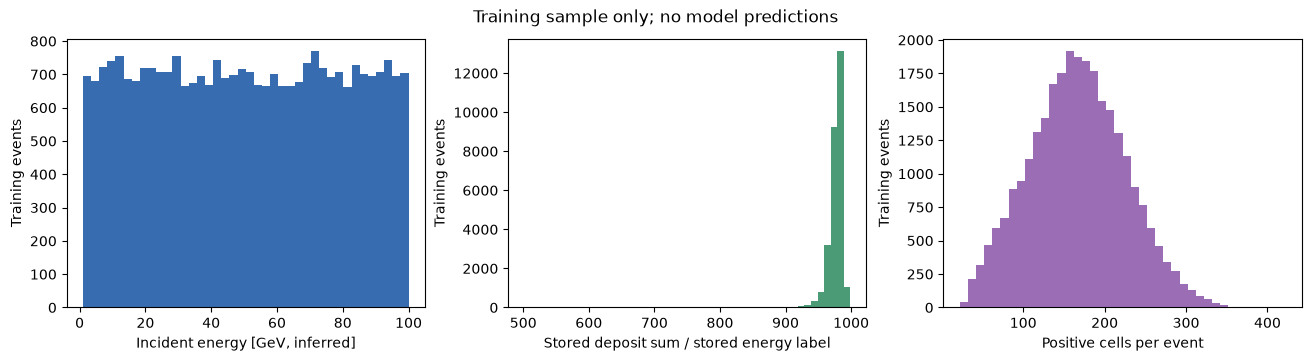

In [8]:
energy = y[:, 0].astype(np.float64)
totals = x.sum(axis=(1, 2), dtype=np.float64)
ratio = totals / energy
occupancy = np.count_nonzero(x, axis=(1, 2))
print("Median raw deposit-sum / energy-label:", float(np.median(ratio)))
print("Median positive-cell count:", float(np.median(occupancy)), "out of 2550")
print(
    "Smallest positive training deposit, stored units:",
    manifest["observations"]["smallest_positive_deposit_as_stored"],
)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
axes[0].hist(energy, bins=40, color="#386cb0")
axes[0].set(xlabel="Incident energy [GeV, inferred]", ylabel="Training events")
axes[1].hist(ratio, bins=50, color="#4b9b76")
axes[1].set(xlabel="Stored deposit sum / stored energy label", ylabel="Training events")
axes[2].hist(occupancy, bins=40, color="#9b6db5")
axes[2].set(xlabel="Positive cells per event", ylabel="Training events")
fig.suptitle("Training sample only; no model predictions")
plt.show()

## 7. Coordinates and documentation differences

| Item | What is established | Remaining limit |
| --- | --- | --- |
| Grid | Axis 0 is local iphi (30 rows); axis 1 is local ieta (85 columns) | Physical cell-center convention remains unresolved |
| Impact iphi | coordinate_0 = float32(InitialRow + 15) | Fractional cell coordinate; not a length or a certified angular value |
| Impact ieta | coordinate_1 = float32(InitialColumn) | Fractional cell coordinate; not a length or eta itself |
| ROOT to NPZ | 10,000 energies, 20,000 coordinates and 25.5 million deposits agree after float32 rounding | Source group 0 checked; other groups not compared to ROOT |
| Cell centers | Plots use explicit array indices; no true-impact overlay | Centers at index versus index + 0.5 are not established for this geometry |

**Study scope:** regress and score the stored coordinates in their own units. An unknown constant origin offset does not invalidate those target-space errors. It does affect the interpretation of a raw barycenter bias or a distance to a physical boundary. An affine calibration can absorb an offset and therefore cannot prove which center convention is correct. No offset is chosen here.

The [source research](../docs/data_audit.md) also establishes:

- **Event count:** the NPZ corpus contains 2.2 million events; the article describes
1.25 million. This is not an exact reproduction of its sample selection.
- **Silicon:** 33 mm (3.3 cm) is supported by both article versions, the material
figure and the author presentation. Zenodo's 33 cm is probably a typo; the actual file-production configuration remains uncertified. No deposit correction follows.
- **Readout:** the article adds noise and then applies a 50 MeV cut. The stored
deposits contain many smaller values and are consistent with an earlier processing stage. Their complete noise history is not certified. Raw-input performance does not establish performance with realistic readout fluctuations.

Sources: [Zenodo record](https://zenodo.org/records/18929909), [article, sections 3.2 and 3.4](https://arxiv.org/html/2603.18172v1), [CaloFound, PDF page 13](https://indico.cern.ch/event/1655754/contributions/7178905/attachments/3338097/5981814/CaloFound_Mode.pdf).


## 8. What changes with a 50 MeV cut?

On train only, the diagnostic temporarily sets deposits below 50 stored units to zero, using the supported MeV interpretation. Every event is retained and the original arrays remain unchanged.

The table reports positive cells and energy removed, plus the shift of the energy-weighted barycenter. The shift uses cell-index units; a constant center offset cancels. It is an input diagnostic, not a model prediction error.


In [9]:
from IPython.display import Markdown, display

threshold_stored = 50.0  # 50 MeV under the supported unit interpretation.
kept_totals = np.zeros(len(x), dtype=np.float64)
kept_cells = np.zeros(len(x), dtype=np.int64)
barycenter_shift = np.full(len(x), np.nan)
iphi_indices = np.arange(x.shape[1])
ieta_indices = np.arange(x.shape[2])

# Small temporary batches avoid another complete copy of the training sample.
for start in range(0, len(x), 256):
    stop = min(start + 256, len(x))
    deposits = x[start:stop]
    cut = np.where(deposits >= threshold_stored, deposits, 0)
    kept_totals[start:stop] = cut.sum(axis=(1, 2), dtype=np.float64)
    kept_cells[start:stop] = np.count_nonzero(cut, axis=(1, 2))
    before = (
        np.column_stack(
            (
                deposits.sum(axis=2, dtype=np.float64) @ iphi_indices,
                deposits.sum(axis=1, dtype=np.float64) @ ieta_indices,
            )
        )
        / totals[start:stop, None]
    )
    after = np.full_like(before, np.nan)
    np.divide(
        np.column_stack(
            (
                cut.sum(axis=2, dtype=np.float64) @ iphi_indices,
                cut.sum(axis=1, dtype=np.float64) @ ieta_indices,
            )
        ),
        kept_totals[start:stop, None],
        out=after,
        where=kept_totals[start:stop, None] > 0,
    )
    barycenter_shift[start:stop] = np.linalg.norm(after - before, axis=1)

assert np.all(kept_totals <= totals)
assert np.all(kept_cells <= occupancy)
print("Events made empty by the cut:", int((kept_totals == 0).sum()))
rows = [
    "| Energy [GeV, inferred] | Events | Positive cells removed [%] | Energy removed [%] "
    "| Median shift [index units] | P95 shift [index units] |",
    "| --- | ---: | ---: | ---: | ---: | ---: |",
]
energy_ranges = [
    ("All train", 0, np.inf),
    ("1 to <10", 1, 10),
    ("10 to <30", 10, 30),
    ("30 to <60", 30, 60),
    ("60 to 100", 60, 101),
]
for name, low, high in energy_ranges:
    selected = (energy >= low) & (energy < high)
    removed_cells = 100 * (1 - kept_cells[selected].sum() / occupancy[selected].sum())
    removed_energy = 100 * (1 - kept_totals[selected].sum() / totals[selected].sum())
    finite_shift = barycenter_shift[selected & np.isfinite(barycenter_shift)]
    median, p95 = np.quantile(finite_shift, [0.5, 0.95])
    rows.append(
        f"| {name} | {int(selected.sum()):,} | {removed_cells:.2f} | {removed_energy:.2f} "
        f"| {median:.4f} | {p95:.4f} |"
    )
display(Markdown("\n".join(rows)))
print("Fractions pool each row; shift quantiles exclude empty events.")


Events made empty by the cut: 0


| Energy [GeV, inferred] | Events | Positive cells removed [%] | Energy removed [%] | Median shift [index units] | P95 shift [index units] |
| --- | ---: | ---: | ---: | ---: | ---: |
| All train | 28,118 | 87.69 | 1.45 | 0.0057 | 0.0234 |
| 1 to <10 | 2,568 | 90.73 | 5.99 | 0.0225 | 0.0575 |
| 10 to <30 | 5,765 | 88.72 | 2.83 | 0.0090 | 0.0212 |
| 30 to <60 | 8,406 | 87.68 | 1.66 | 0.0060 | 0.0125 |
| 60 to 100 | 11,379 | 87.17 | 1.11 | 0.0039 | 0.0088 |

Fractions pool each row; shift quantiles exclude empty events.


## 9. From the audit to the selected method

The cut-only diagnostic removes **87.69% of positive cells but 1.45% of total deposited energy**; for events below 10 GeV, the energy fraction removed rises to **5.99%**. This calculation uses clean deposits. Its percentages must not be substituted for a noise-plus-cut measurement.

Subsequent experiments compared clean inputs, noise and thresholding, task sharing, and local versus full-grid models. Their results now motivate a **local 7 x 7 input, separate task training, and matched noise-plus-cut training/evaluation**, with clean and noise-only controls. See [Methods and decisions](02_methods_and_decisions.ipynb) and the [selected protocol](../docs/methodology.md).

The [source study](https://arxiv.org/html/2603.18172v2#S3.SS4) motivates the simplified noise response and cell threshold; it does not validate this prototype on real detector data. Position errors remain in stored coordinate units, without a physical cell-center interpretation.

The selected GPU training and held-out evaluation are now complete; see [Final results](04_final_results.ipynb). The audit remains descriptive and performs no model training. Provenance, source checks and geometry limits are consolidated in the [data report](../docs/data_audit.md).
